# Maneuver Classification

**Task:** 3-class classification of flight maneuvers from variable-length time-series (x, y, z measurements).  
**Scoring metric:** Minimum F1 score across the 3 classes.

---
### Pipeline
1. Data loading & sanity checks  
2. EDA & visualisations  
3. Feature extraction (statistical · temporal · frequency-domain · cross-channel)  
4. Model training with stratified cross-validation  
5. Evaluation: F1 / Precision / Recall, confusion matrix, feature importance  
6. Test-set inference & submission file

## 0. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats, signal
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb


SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = sns.color_palette('Set2', 3)
CLASS_NAMES = {0: 'Class 0', 1: 'Class 1', 2: 'Class 2'}

print("All imports successful")

All imports successful


## 1. Data Loading

In [2]:
TRAIN_PATH = 'train_set.csv'
TEST_PATH  = 'test_set.csv'
SUB_PATH   = 'submission_example.csv'

train_raw = pd.read_csv(TRAIN_PATH)
#print(train_raw)
test_raw  = pd.read_csv(TEST_PATH)
#print(test_raw)
sub_ex    = pd.read_csv(SUB_PATH)


print(f"Train : {train_raw.shape[0]:,} rows | {train_raw['maneuver_Id'].nunique():,} maneuvers")
print(f"Test  : {test_raw.shape[0]:,} rows  | {test_raw['maneuver_Id'].nunique():,} maneuvers")
print(f"Test maneuver_Id range : {test_raw['maneuver_Id'].min()} → {test_raw['maneuver_Id'].max()}")
print()
print("Train sample:")
display(train_raw.head())
print("\nTest sample:")
display(test_raw.head())

Train : 799,994 rows | 25,706 maneuvers
Test  : 200,000 rows  | 6,351 maneuvers
Test maneuver_Id range : 25705 → 32055

Train sample:


,maneuver_Id,timestamp,measurement_x,measurement_y,measurement_z,label
0,0,50:34.3,0.798000,-0.023776,0.080064,1
1,0,50:34.4,0.795484,-0.031727,0.077065,1
2,0,50:34.4,0.793049,-0.039704,0.077875,1
3,0,50:34.5,0.790697,-0.047705,0.076800,1
4,0,50:34.5,0.788426,-0.055730,0.079076,1



Test sample:


,maneuver_Id,timestamp,measurement_x,measurement_y,measurement_z
0,25705,2015-10-10 23:40:29.106000,0.528361,0.197757,0.061193
1,25705,2015-10-10 23:40:29.106000,0.528195,0.202128,0.062136
2,25705,2015-10-10 23:40:29.206000,0.527988,0.206497,0.059240
3,25705,2015-10-10 23:40:29.256000,0.527739,0.210864,0.056590
4,25705,2015-10-10 23:40:29.306000,0.527449,0.215228,0.053298


### 1.1 Timestamp Parsing

> **Note:** Train timestamps use `MM:SS.f` format while test timestamps are full ISO datetimes.  
> We convert both to elapsed seconds *within each maneuver* for temporal features.

In [3]:
# ── Train: "MM:SS.f" → float seconds ──────────────────────────────────────────
def parse_ts_train(ts):
    try:
        m, s = str(ts).split(':')
        return float(m) * 60 + float(s)
    except Exception:
        return np.nan

train_raw['ts_seconds'] = train_raw['timestamp'].apply(parse_ts_train)

# ── Test: full ISO datetime → float seconds ────────────────────────────────────
test_raw['ts_seconds'] = pd.to_datetime(test_raw['timestamp'], format='mixed').astype('int64') / 1e9

# ── Elapsed time within maneuver ───────────────────────────────────────────────
for df in [train_raw, test_raw]:
    df['ts_elapsed'] = df.groupby('maneuver_Id')['ts_seconds'].transform(
        lambda x: x - x.min()
    )

print("Timestamp parsing done.")
print("Train ts_seconds sample :", train_raw['ts_seconds'].head(3).tolist())
print("Test  ts_seconds sample  :", test_raw['ts_seconds'].head(3).tolist())
print("\nMissing values (train):")
print(train_raw[['measurement_x','measurement_y','measurement_z']].isnull().sum())

Timestamp parsing done.
Train ts_seconds sample : [3034.3, 3034.4, 3034.4]
Test  ts_seconds sample  : [1444520.429106, 1444520.429106, 1444520.429206]

Missing values (train):
measurement_x    798
measurement_y    156
measurement_z    145
dtype: int64


## 2. Exploratory Data Analysis (EDA)

In [4]:
MEAS = ['measurement_x', 'measurement_y', 'measurement_z']

# ── Maneuver-level labels ──────────────────────────────────────────────────────
maneuver_labels = train_raw.groupby('maneuver_Id')['label'].first()
class_counts = maneuver_labels.value_counts().sort_index()

print("── Class distribution (maneuver level) ──")
for cls, cnt in class_counts.items():
    pct = cnt / class_counts.sum() * 100
    print(f"  Class {cls}: {cnt:5,} maneuvers ({pct:.1f}%)")
print()
print("Heavy imbalance")

── Class distribution (maneuver level) ──
  Class 0: 17,613 maneuvers (68.5%)
  Class 1: 6,214 maneuvers (24.2%)
  Class 2: 1,879 maneuvers (7.3%)

Heavy imbalance


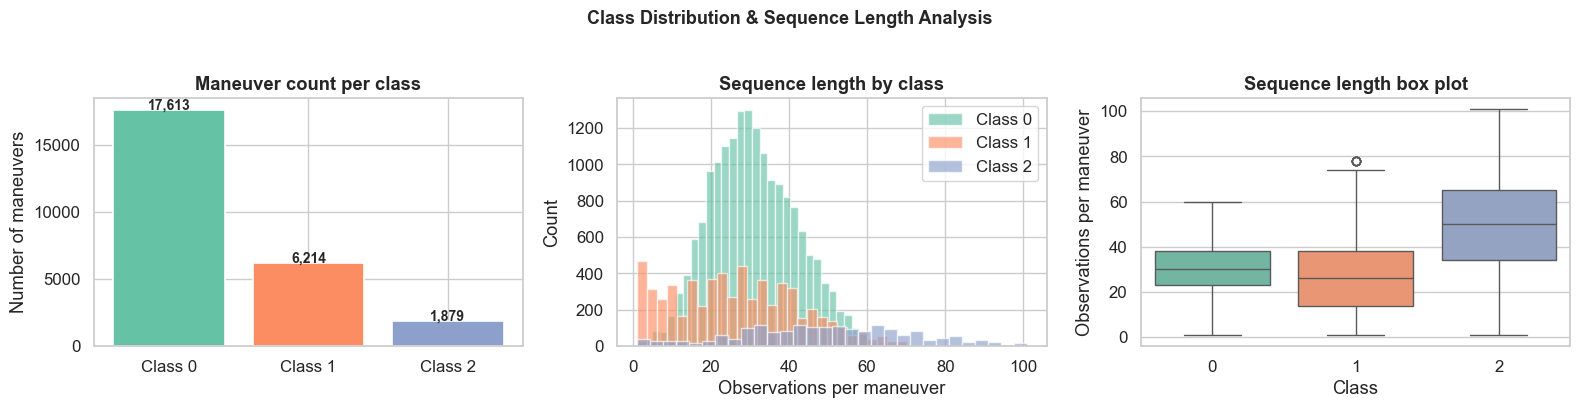

         count  mean   std  min   25%   50%   75%    max
label                                                   
0      17613.0  30.7  11.1  1.0  23.0  30.0  38.0   60.0
1       6214.0  26.7  16.3  1.0  14.0  26.0  38.0   78.0
2       1879.0  49.5  21.6  1.0  34.0  50.0  65.0  101.0


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Class bar chart
bars = axes[0].bar([f'Class {c}' for c in class_counts.index],
                   class_counts.values, color=COLORS, edgecolor='white', linewidth=1.2)
axes[0].set_title('Maneuver count per class', fontweight='bold')
axes[0].set_ylabel('Number of maneuvers')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 20,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# (b) Sequence length distribution
seq_lengths = train_raw.groupby('maneuver_Id').size().reset_index(name='n_obs')
seq_lengths['label'] = maneuver_labels.values

for i, cls in enumerate(sorted(seq_lengths['label'].unique())):
    subset = seq_lengths[seq_lengths['label'] == cls]['n_obs']
    axes[1].hist(subset, bins=30, alpha=0.65, label=f'Class {cls}', color=COLORS[i], edgecolor='white')
axes[1].set_title('Sequence length by class', fontweight='bold')
axes[1].set_xlabel('Observations per maneuver')
axes[1].set_ylabel('Count')
axes[1].legend()

# (c) Sequence length boxplot
sns.boxplot(data=seq_lengths, x='label', y='n_obs', palette=COLORS, ax=axes[2],
            order=sorted(seq_lengths['label'].unique()))
axes[2].set_title('Sequence length box plot', fontweight='bold')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Observations per maneuver')

plt.suptitle('Class Distribution & Sequence Length Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(seq_lengths.groupby('label')['n_obs'].describe().round(1))

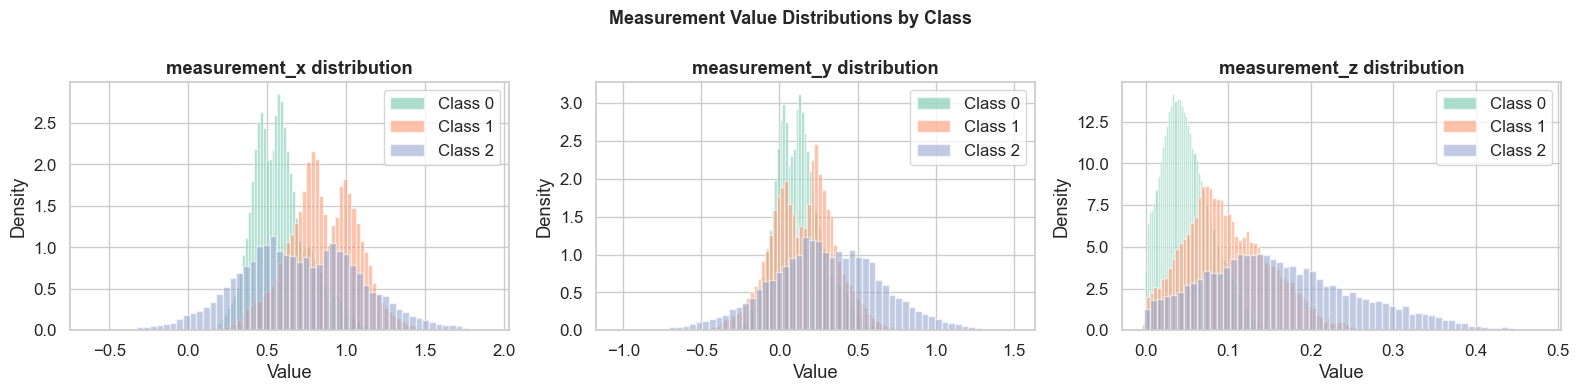

In [6]:
# ── Per-class measurement distributions ───────────────────────────────────────
classes = sorted(maneuver_labels.unique())
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, meas in zip(axes, MEAS):
    for i, cls in enumerate(classes):
        ids = maneuver_labels[maneuver_labels == cls].index
        vals = train_raw[train_raw['maneuver_Id'].isin(ids)][meas].dropna()
        ax.hist(vals, bins=60, alpha=0.55, label=f'Class {cls}', color=COLORS[i], density=True)
    ax.set_title(f'{meas} distribution', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Measurement Value Distributions by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

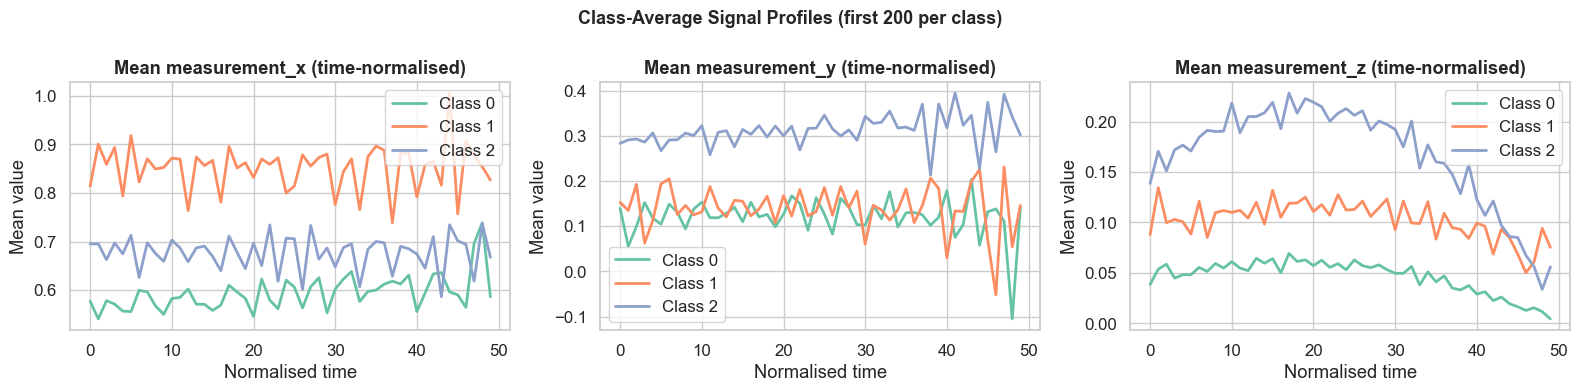

In [7]:
# ── Per-maneuver mean signal per class ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, meas in zip(axes, MEAS):
    for i, cls in enumerate(classes):
        ids = maneuver_labels[maneuver_labels == cls].index[:200]
        grp = train_raw[train_raw['maneuver_Id'].isin(ids)].copy()
        # Normalise time to [0,1] per maneuver for alignment
        grp['t_norm'] = grp.groupby('maneuver_Id')['ts_elapsed'].transform(
            lambda x: x / x.max() if x.max() > 0 else x
        )
        grp['t_bin'] = pd.cut(grp['t_norm'], bins=50, labels=False)
        mean_sig = grp.groupby('t_bin')[meas].mean()
        ax.plot(mean_sig.index, mean_sig.values, color=COLORS[i], label=f'Class {cls}', linewidth=2)
    ax.set_title(f'Mean {meas} (time-normalised)', fontweight='bold')
    ax.set_xlabel('Normalised time')
    ax.set_ylabel('Mean value')
    ax.legend()

plt.suptitle('Class-Average Signal Profiles (first 200 per class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Feature Extraction

We compute **per-maneuver aggregate features** grouped into:
- **Statistical** — mean, std, min, max, median, percentiles, skew, kurtosis, IQR, range, RMS
- **Temporal** — duration, mean/std inter-sample interval, linear trend slope, first-difference stats
- **Frequency-domain** — dominant FFT frequency, spectral energy, spectral centroid
- **Magnitude** — derived `||(x,y,z)||` channel stats
- **Cross-channel** — pairwise Pearson correlations + Chatterjee (XICOR) in both directions
- **Sequence** — observation count

In [8]:
def extract_features(df, meas_cols=None, ts_col='ts_elapsed'):
    """
    Extract aggregate features from one maneuver's time-series DataFrame.
    Returns a flat dict of features.
    """
    if meas_cols is None:
        meas_cols = ['measurement_x', 'measurement_y', 'measurement_z']

    feat = {}
    df = df.sort_values(ts_col).reset_index(drop=True)

    # ── 1. Sequence metadata ──────────────────────────────────────────────────
    n = len(df)
    feat['n_obs'] = n
    t = df[ts_col].values

    # ── 2. Temporal features ──────────────────────────────────────────────────
    duration = t[-1] - t[0] if n > 1 else 0.0
    feat['duration'] = duration
    if n > 1:
        dt = np.diff(t)
        feat['dt_mean'] = dt.mean()
        feat['dt_std']  = dt.std()
        feat['dt_min']  = dt.min()
        feat['dt_max']  = dt.max()
    else:
        feat['dt_mean'] = feat['dt_std'] = feat['dt_min'] = feat['dt_max'] = 0.0

    # ── 3. Per-channel statistical + temporal + frequency features ─────────────
    for col in meas_cols:
        suffix = col.split('_')[-1]   # 'x', 'y', 'z'
        vals = df[col].ffill().bfill().values.astype(float)

        if len(vals) == 0:
            continue

        # --- Statistical ---
        feat[f'{suffix}_mean']   = np.mean(vals)
        feat[f'{suffix}_std']    = np.std(vals)
        feat[f'{suffix}_min']    = np.min(vals)
        feat[f'{suffix}_max']    = np.max(vals)
        feat[f'{suffix}_range']  = np.ptp(vals)
        feat[f'{suffix}_median'] = np.median(vals)
        feat[f'{suffix}_p25']    = np.percentile(vals, 25)
        feat[f'{suffix}_p75']    = np.percentile(vals, 75)
        feat[f'{suffix}_iqr']    = feat[f'{suffix}_p75'] - feat[f'{suffix}_p25']
        feat[f'{suffix}_rms']    = np.sqrt(np.mean(vals**2))
        feat[f'{suffix}_skew']   = float(stats.skew(vals))
        feat[f'{suffix}_kurt']   = float(stats.kurtosis(vals))
        feat[f'{suffix}_abs_mean'] = np.mean(np.abs(vals))
        feat[f'{suffix}_energy'] = np.sum(vals**2)

        # --- Zero crossings (around mean) ---
        centered = vals - np.mean(vals)
        feat[f'{suffix}_zc'] = int(np.sum(np.diff(np.sign(centered)) != 0))

        # --- Temporal trend: linear regression slope vs time ---
        if n > 1 and np.unique(t).size > 1:
            slope, intercept, _, _, _ = stats.linregress(t, vals)
            feat[f'{suffix}_slope'] = slope
            fitted = slope * t + intercept
            feat[f'{suffix}_resid_std'] = np.std(vals - fitted)
        else:
            feat[f'{suffix}_slope'] = 0.0
            feat[f'{suffix}_resid_std'] = 0.0

        # --- First differences ---
        if n > 1:
            dvals = np.diff(vals)
            feat[f'{suffix}_diff_mean']  = np.mean(dvals)
            feat[f'{suffix}_diff_std']   = np.std(dvals)
            feat[f'{suffix}_diff_abs_mean'] = np.mean(np.abs(dvals))
            feat[f'{suffix}_diff_max']   = np.max(np.abs(dvals))
        else:
            feat[f'{suffix}_diff_mean'] = feat[f'{suffix}_diff_std'] = 0.0
            feat[f'{suffix}_diff_abs_mean'] = feat[f'{suffix}_diff_max'] = 0.0

        # --- Autocorrelation at lag 1 ---
        if n > 2:
            feat[f'{suffix}_autocorr1'] = pd.Series(vals).autocorr(lag=1)
        else:
            feat[f'{suffix}_autocorr1'] = 0.0

        # --- Frequency domain (FFT) ---
        if n >= 4:
            N = len(vals)
            yf = np.abs(fft(vals - np.mean(vals)))[:N // 2]
            xf = fftfreq(N, d=feat['dt_mean'] if feat['dt_mean'] > 0 else 0.1)[:N // 2]
            if yf.sum() > 0:
                feat[f'{suffix}_fft_dom_freq']   = float(xf[np.argmax(yf)])
                feat[f'{suffix}_fft_energy']     = float(np.sum(yf**2))
                feat[f'{suffix}_fft_centroid']   = float(np.sum(xf * yf) / np.sum(yf))
                feat[f'{suffix}_fft_entropy']    = float(stats.entropy(yf / yf.sum() + 1e-12))
            else:
                feat[f'{suffix}_fft_dom_freq']   = 0.0
                feat[f'{suffix}_fft_energy']     = 0.0
                feat[f'{suffix}_fft_centroid']   = 0.0
                feat[f'{suffix}_fft_entropy']    = 0.0
        else:
            for k in ['fft_dom_freq','fft_energy','fft_centroid','fft_entropy']:
                feat[f'{suffix}_{k}'] = 0.0

    # ── 4. Magnitude channel ──────────────────────────────────────────────────
    x = df['measurement_x'].fillna(0).values.astype(float)
    y = df['measurement_y'].fillna(0).values.astype(float)
    z = df['measurement_z'].fillna(0).values.astype(float)
    mag = np.sqrt(x**2 + y**2 + z**2)

    feat['mag_mean']   = np.mean(mag)
    feat['mag_std']    = np.std(mag)
    feat['mag_min']    = np.min(mag)
    feat['mag_max']    = np.max(mag)
    feat['mag_range']  = np.ptp(mag)
    feat['mag_skew']   = float(stats.skew(mag))
    feat['mag_kurt']   = float(stats.kurtosis(mag))
    if n > 1 and np.unique(t).size > 1:
        slope_m, _, _, _, _ = stats.linregress(t, mag)
        feat['mag_slope'] = slope_m
    else:
        feat['mag_slope'] = 0.0

    # ── 5. Cross-channel correlations ─────────────────────────────────────────
    pairs = [('x','y'), ('x','z'), ('y','z')]
    col_map = {'x':'measurement_x', 'y':'measurement_y', 'z':'measurement_z'}
    for a, b in pairs:
        va = df[col_map[a]].fillna(0).values
        vb = df[col_map[b]].fillna(0).values
        if len(va) > 2 and np.std(va) > 0 and np.std(vb) > 0:
            feat[f'corr_{a}{b}'] = float(np.corrcoef(va, vb)[0, 1])
        else:
            feat[f'corr_{a}{b}'] = 0.0

    # ── 6. Chatterjee correlation (XICOR) ─────────────────────────────────────
    # Detects any functional dependency, not just linear — no parameter tuning needed.
    # Ref: Sourav Chatterjee (2021), "A New Coefficient of Correlation"
    def xicor(x, y):
        n = len(x)
        if n < 4:
            return 0.0
        order = np.argsort(x)
        y_sorted = y[order]
        r = np.argsort(np.argsort(y_sorted)) + 1  # ranks of y after sorting by x
        # xi = 1 - 3 * sum(|r_i - r_{i+1}|) / (n^2 - 1)
        return float(1.0 - 3.0 * np.sum(np.abs(np.diff(r))) / (n**2 - 1))

    for a, b in pairs:
        va = df[col_map[a]].fillna(0).values.astype(float)
        vb = df[col_map[b]].fillna(0).values.astype(float)
        feat[f'xi_{a}{b}'] = xicor(va, vb)
        feat[f'xi_{b}{a}'] = xicor(vb, va)  # asymmetric — both directions

    return feat


print("Feature extraction function defined.")
print("Testing on maneuver 0 ...")
sample_feats = extract_features(train_raw[train_raw['maneuver_Id'] == 0])
print(f"  → {len(sample_feats)} features extracted")
print("  Sample keys:", list(sample_feats.keys())[:15])

Feature extraction function defined.
Testing on maneuver 0 ...
  → 101 features extracted
  Sample keys: ['n_obs', 'duration', 'dt_mean', 'dt_std', 'dt_min', 'dt_max', 'x_mean', 'x_std', 'x_min', 'x_max', 'x_range', 'x_median', 'x_p25', 'x_p75', 'x_iqr']


In [9]:
# ── Apply feature extraction to all maneuvers ─────────────────────────────────
from tqdm.auto import tqdm

def build_feature_matrix(df, label_col=None):
    records = []
    grouped = df.groupby('maneuver_Id')
    for mid, group in tqdm(grouped, desc='Extracting features'):
        feat = extract_features(group)
        feat['maneuver_Id'] = mid
        if label_col and label_col in group.columns:
            feat['label'] = group[label_col].iloc[0]
        records.append(feat)
    return pd.DataFrame(records)

print("Building TRAIN feature matrix ...")
train_feat = build_feature_matrix(train_raw, label_col='label')
print(f"  → {train_feat.shape[0]} maneuvers × {train_feat.shape[1]} columns")

print("\nBuilding TEST feature matrix ...")
test_feat = build_feature_matrix(test_raw)
print(f"  → {test_feat.shape[0]} maneuvers × {test_feat.shape[1]} columns")

Building TRAIN feature matrix ...


Extracting features: 100%|██████████| 25706/25706 [16:07<00:00, 26.57it/s]  


  → 25706 maneuvers × 103 columns

Building TEST feature matrix ...


Extracting features: 100%|██████████| 6351/6351 [03:39<00:00, 28.89it/s]


  → 6351 maneuvers × 102 columns


In [10]:
# ── Sanity check ──────────────────────────────────────────────────────────────
print("Train features — missing values:")
print(train_feat.isnull().sum()[train_feat.isnull().sum() > 0])

print("\nFeature matrix preview:")
display(train_feat.head(3))

FEATURE_COLS = [c for c in train_feat.columns if c not in ['maneuver_Id','label']]
print(f"\nTotal features: {len(FEATURE_COLS)}")

Train features — missing values:
duration       112
dt_mean        112
dt_std         112
dt_min         112
dt_max         112
x_skew         186
x_kurt         186
x_slope        112
x_resid_std    112
y_skew         186
y_kurt         186
y_slope        112
y_resid_std    112
z_skew         186
z_kurt         186
z_slope        112
z_resid_std    112
mag_skew       186
mag_kurt       186
mag_slope      112
dtype: int64

Feature matrix preview:


,n_obs,duration,dt_mean,dt_std,dt_min,dt_max,x_mean,x_std,x_min,x_max,...,corr_xz,corr_yz,xi_xy,xi_yx,xi_xz,xi_zx,xi_yz,xi_zy,maneuver_Id,label
0,25,1.2,0.05,0.05,0.0,0.1,0.775444,0.011409,0.760623,0.798,...,0.891432,0.956743,0.884615,0.884615,0.798077,0.807692,0.798077,0.807692,0,1
1,31,1.5,0.05,0.05,0.0,0.1,0.779810,0.013579,0.760623,0.798,...,-0.269814,0.860703,0.831250,0.812500,0.737500,0.500000,0.787500,0.675000,1,1
2,31,1.5,0.05,0.05,0.0,0.1,0.779810,0.013579,0.760623,0.798,...,-0.269814,0.860703,0.831250,0.812500,0.737500,0.500000,0.787500,0.675000,2,1



Total features: 101


In [11]:
# ── Fill any remaining NaNs ────────────────────────────────────────────────────
train_feat[FEATURE_COLS] = train_feat[FEATURE_COLS].fillna(0)
test_feat[FEATURE_COLS]  = test_feat[FEATURE_COLS].fillna(0)

X = train_feat[FEATURE_COLS].values
y = train_feat['label'].values
X_test = test_feat[FEATURE_COLS].values

print("X shape:", X.shape)
print("y shape:", y.shape, " | classes:", np.unique(y, return_counts=True))
print("X_test shape:", X_test.shape)

X shape: (25706, 101)
y shape: (25706,)  | classes: (array([0, 1, 2]), array([17613,  6214,  1879]))
X_test shape: (6351, 101)


### 3.1 Feature Correlation Overview

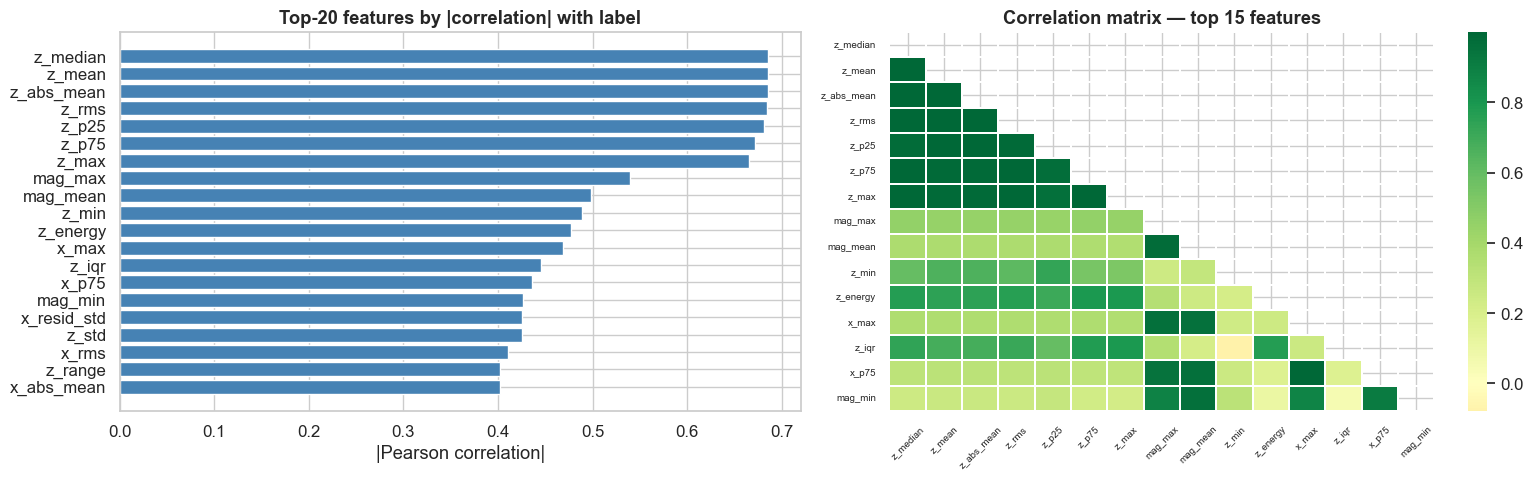

Top-10 features by |correlation| with label:
z_median      0.685852
z_mean        0.685446
z_abs_mean    0.685440
z_rms         0.684584
z_p25         0.681756
z_p75         0.672090
z_max         0.665426
mag_max       0.539555
mag_mean      0.498933
z_min         0.489362


In [12]:
# ── Correlation of top statistical features with label ─────────────────────────
corr_with_label = (
    train_feat[FEATURE_COLS + ['label']]
    .corr()['label']
    .drop('label')
    .abs()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top-20 features by correlation with label
top20 = corr_with_label.head(20)
axes[0].barh(top20.index[::-1], top20.values[::-1], color='steelblue', edgecolor='white')
axes[0].set_title('Top-20 features by |correlation| with label', fontweight='bold')
axes[0].set_xlabel('|Pearson correlation|')

# Heatmap of top-15 feature correlations
top15_feats = corr_with_label.head(15).index.tolist()
corr_mat = train_feat[top15_feats].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, cmap='RdYlGn', center=0,
            ax=axes[1], annot=False, linewidths=0.3,
            xticklabels=True, yticklabels=True)
axes[1].set_title('Correlation matrix — top 15 features', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

print("Top-10 features by |correlation| with label:")
print(corr_with_label.head(10).to_string())

## 4. Model Training & Cross-Validation

**Strategy:**
- 5-fold stratified CV to preserve class proportions
- `class_weight='balanced'` on all models to address the severe imbalance
- Optimise for **minimum per-class F1** (the actual scoring metric)
- Compare multiple algorithms; select best for submission

In [13]:
import sklearn
print(sklearn.__version__)
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def min_f1(y_true, y_pred):
    """Custom scorer: minimum F1 across classes (actual competition metric)."""
    f1s = f1_score(y_true, y_pred, average=None, zero_division=0)
    return f1s.min()

# ── Define candidate models ────────────────────────────────────────────────────
models = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=500, max_depth=None, min_samples_leaf=2,
            class_weight='balanced', n_jobs=-1, random_state=SEED
        ))
    ]),
    'Extra Trees': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', ExtraTreesClassifier(
            n_estimators=500, min_samples_leaf=2,
            class_weight='balanced', n_jobs=-1, random_state=SEED
        ))
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=1.0, max_iter=2000, class_weight='balanced',
            n_jobs=-1, random_state=SEED
        ))
    ]),
}

models['XGBoost'] = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', xgb.XGBClassifier(
            n_estimators=400, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric='mlogloss',
            n_jobs=-1, random_state=SEED
        ))
    ])


models['LightGBM'] = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', lgb.LGBMClassifier(
            n_estimators=400, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            class_weight='balanced',
            n_jobs=-1, random_state=SEED, verbose=-1
        ))
    ])

print("Models to evaluate:")
for name in models:
    print(f"  · {name}")

1.8.0
Models to evaluate:
  · Random Forest
  · Extra Trees
  · Logistic Regression
  · XGBoost
  · LightGBM


In [14]:
from sklearn.utils.class_weight import compute_sample_weight

results = {}

for name, model in models.items():
    print(f"\n{'─'*50}")
    print(f"Training: {name}")
    
    # For XGBoost we pass sample_weight because it doesn't support class_weight natively
    fit_params = {}
    if 'XGBoost' in name:
        sw = compute_sample_weight('balanced', y)
        fit_params = {'clf__sample_weight': sw}
    
    y_pred_cv = cross_val_predict(
    model, X, y,
    cv=CV,
    params=fit_params,   # <-- changed here
    n_jobs=-1
    )
    
    f1_per_class = f1_score(y, y_pred_cv, average=None, zero_division=0)
    f1_macro     = f1_score(y, y_pred_cv, average='macro', zero_division=0)
    min_f1_score = f1_per_class.min()
    
    results[name] = {
        'y_pred': y_pred_cv,
        'f1_per_class': f1_per_class,
        'f1_macro': f1_macro,
        'min_f1': min_f1_score,
    }
    
    print(f"  F1 per class : {f1_per_class.round(3)}")
    print(f"  Macro F1     : {f1_macro:.4f}")
    print(f"  * Min F1 (score): {min_f1_score:.4f}")

print("\n" + "═"*50)
print("Model comparison (sorted by Min F1):")
summary = pd.DataFrame({
    name: {
        'Min F1 *': v['min_f1'],
        'Macro F1': v['f1_macro'],
        'F1 Class-0': v['f1_per_class'][0],
        'F1 Class-1': v['f1_per_class'][1],
        'F1 Class-2': v['f1_per_class'][2],
    }
    for name, v in results.items()
}).T.sort_values('Min F1 *', ascending=False)

display(summary.round(4))
best_model_name = summary.index[0]
print(f"\n Best model: {best_model_name} (Min F1 = {summary.loc[best_model_name, 'Min F1 *']:.4f})")


──────────────────────────────────────────────────
Training: Random Forest
  F1 per class : [0.999 0.996 0.991]
  Macro F1     : 0.9954
  * Min F1 (score): 0.9909

──────────────────────────────────────────────────
Training: Extra Trees
  F1 per class : [0.999 0.997 0.992]
  Macro F1     : 0.9961
  * Min F1 (score): 0.9920

──────────────────────────────────────────────────
Training: Logistic Regression
  F1 per class : [0.968 0.872 0.828]
  Macro F1     : 0.8894
  * Min F1 (score): 0.8282

──────────────────────────────────────────────────
Training: XGBoost
  F1 per class : [1.    0.999 0.998]
  Macro F1     : 0.9991
  * Min F1 (score): 0.9984

──────────────────────────────────────────────────
Training: LightGBM
  F1 per class : [1.    0.999 0.998]
  Macro F1     : 0.9991
  * Min F1 (score): 0.9984

══════════════════════════════════════════════════
Model comparison (sorted by Min F1):


,Min F1 *,Macro F1,F1 Class-0,F1 Class-1,F1 Class-2
LightGBM,0.9984,0.9991,0.9997,0.9993,0.9984
XGBoost,0.9984,0.9991,0.9998,0.9990,0.9984
Extra Trees,0.9920,0.9961,0.9993,0.9971,0.9920
Random Forest,0.9909,0.9954,0.9991,0.9962,0.9909
Logistic Regression,0.8282,0.8894,0.9685,0.8716,0.8282



 Best model: LightGBM (Min F1 = 0.9984)


## 5. Evaluation

In [15]:
## 4.1 Hyperparameter Tuning (Best Model)
from sklearn.metrics import make_scorer
from sklearn.model_selection import RandomizedSearchCV

min_f1_scorer = make_scorer(min_f1)

param_dist = {
    'Random Forest': {
        'clf__n_estimators': [300, 500, 800],
        'clf__max_depth': [4, 6, 8, None],
        'clf__min_samples_leaf': [1, 2, 5, 10],
        'clf__max_features': ['sqrt', 'log2', 0.3],
    },
    'Extra Trees': {
        'clf__n_estimators': [300, 500, 800],
        'clf__max_depth': [4, 6, 8, None],
        'clf__min_samples_leaf': [1, 2, 5, 10],
    },
    'XGBoost': {
        'clf__n_estimators': [200, 400, 600],
        'clf__max_depth': [4, 6, 8],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__subsample': [0.7, 0.8, 1.0],
        'clf__colsample_bytree': [0.7, 0.8, 1.0],
        'clf__min_child_weight': [1, 3, 5],
    },
    'LightGBM': {
        'clf__n_estimators': [200, 400, 600],
        'clf__max_depth': [4, 6, 8],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__num_leaves': [31, 63, 127],
        'clf__min_child_samples': [10, 20, 50],
    },
    'Logistic Regression': {
        'clf__C': [0.01, 0.1, 1.0, 10.0],
    },
}

fit_params_tuning = {}
if 'XGBoost' in best_model_name:
    fit_params_tuning = {'clf__sample_weight': compute_sample_weight('balanced', y)}

search = RandomizedSearchCV(
    models[best_model_name],
    param_dist[best_model_name],
    n_iter=5,
    scoring=min_f1_scorer,
    cv=CV,
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
)
search.fit(X, y, **fit_params_tuning)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__learning_rate': [0.01, 0.05, ...], 'clf__max_depth': [4, 6, ...], 'clf__min_child_samples': [10, 20, ...], 'clf__n_estimators': [200, 400, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross

In [16]:
print(f"Best params : {search.best_params_}")
print(f"Best min-F1 : {search.best_score_:.4f}  (vs baseline {results[best_model_name]['min_f1']:.4f})")

# Swap in the tuned model for evaluation and submission
best_pipeline = search.best_estimator_

Best params : {'clf__num_leaves': 127, 'clf__n_estimators': 600, 'clf__min_child_samples': 20, 'clf__max_depth': 8, 'clf__learning_rate': 0.05}
Best min-F1 : 0.9987  (vs baseline 0.9984)


In [17]:
best_res = results[best_model_name]
y_pred_best = best_res['y_pred']

# ── (a) Classification report ─────────────────────────────────────────────────
print(f"=== Classification Report — {best_model_name} (5-fold CV) ===\n")
print(classification_report(y, y_pred_best, target_names=[f'Class {i}' for i in range(3)]))

=== Classification Report — LightGBM (5-fold CV) ===

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00     17613
     Class 1       1.00      1.00      1.00      6214
     Class 2       1.00      1.00      1.00      1879

    accuracy                           1.00     25706
   macro avg       1.00      1.00      1.00     25706
weighted avg       1.00      1.00      1.00     25706



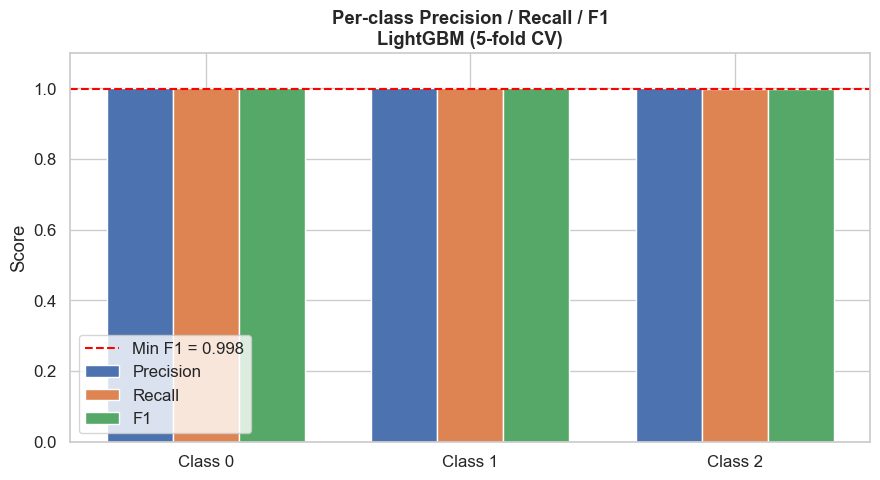

Min F1 (competition score): 0.9984


In [18]:
# ── (b) Per-class Precision / Recall / F1 bar chart ──────────────────────────
prec = precision_score(y, y_pred_best, average=None, zero_division=0)
rec  = recall_score(y, y_pred_best, average=None, zero_division=0)
f1s  = f1_score(y, y_pred_best, average=None, zero_division=0)

x_pos = np.arange(3)
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x_pos - width, prec, width, label='Precision', color='#4C72B0')
ax.bar(x_pos,         rec,  width, label='Recall',    color='#DD8452')
ax.bar(x_pos + width, f1s,  width, label='F1',        color='#55A868')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'Class {i}' for i in range(3)])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title(f'Per-class Precision / Recall / F1\n{best_model_name} (5-fold CV)',
             fontweight='bold')
ax.legend()
ax.axhline(min(f1s), color='red', linestyle='--', linewidth=1.5, label=f'Min F1 = {min(f1s):.3f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Min F1 (competition score): {min(f1s):.4f}")

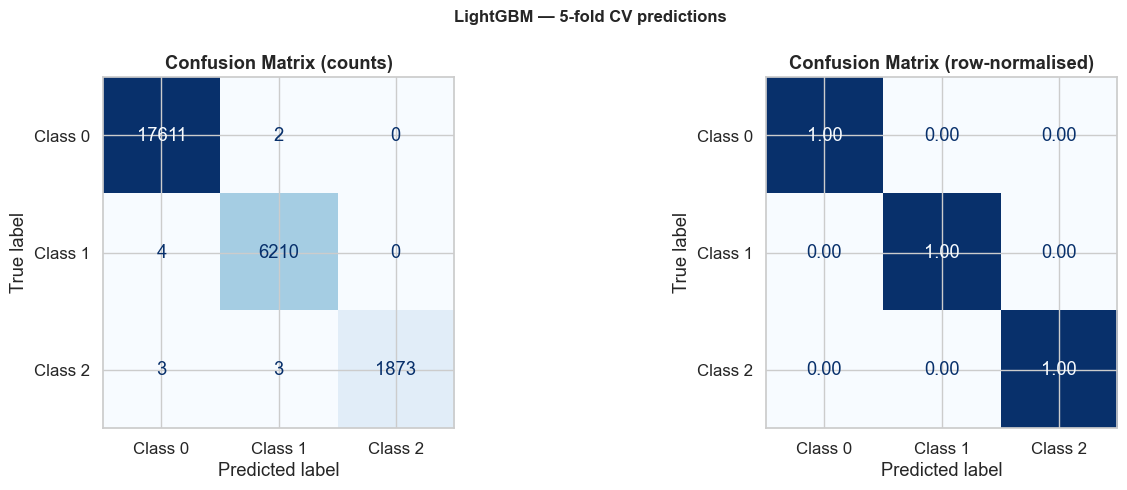

In [19]:
# ── (c) Confusion matrix ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
cm = confusion_matrix(y, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[f'Class {i}' for i in range(3)])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')

# Normalised (recall-normalised = row-normalised)
cm_norm = confusion_matrix(y, y_pred_best, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=[f'Class {i}' for i in range(3)])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2f')
axes[1].set_title('Confusion Matrix (row-normalised)', fontweight='bold')

plt.suptitle(f'{best_model_name} — 5-fold CV predictions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.1 Feature Importance — SHAP

In [20]:
import shap

clf = best_pipeline.named_steps['clf']
scaler = best_pipeline.named_steps['scaler']
X_scaled = scaler.transform(X)

# subsample for speed — SHAP importance is stable at 500 rows
rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_scaled), size=500, replace=False)
X_shap = X_scaled[idx]

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_abs_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
else:
    shap_abs_mean = np.abs(shap_values)

print(f"SHAP computed on {X_shap.shape[0]} samples × {X_shap.shape[1]} features")

SHAP computed on 500 samples × 101 features


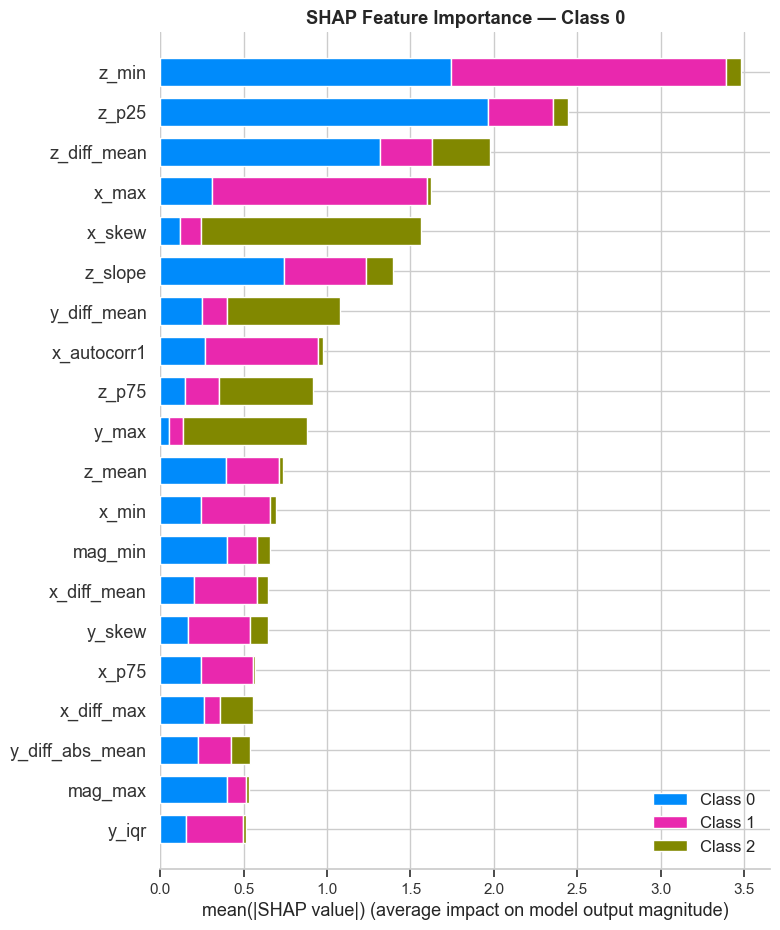

In [23]:
# Global summary — beeswarm plot (one panel per class)
n_classes = len(shap_values) if isinstance(shap_values, list) else 1

for i in range(n_classes):
    sv = shap_values[i] if isinstance(shap_values, list) else shap_values
    shap.summary_plot(sv, X_shap, feature_names=FEATURE_COLS,
                      plot_type='bar', show=False, max_display=20)
    plt.title(f'SHAP Feature Importance — Class {i}', fontweight='bold')
    plt.tight_layout()
    plt.show()

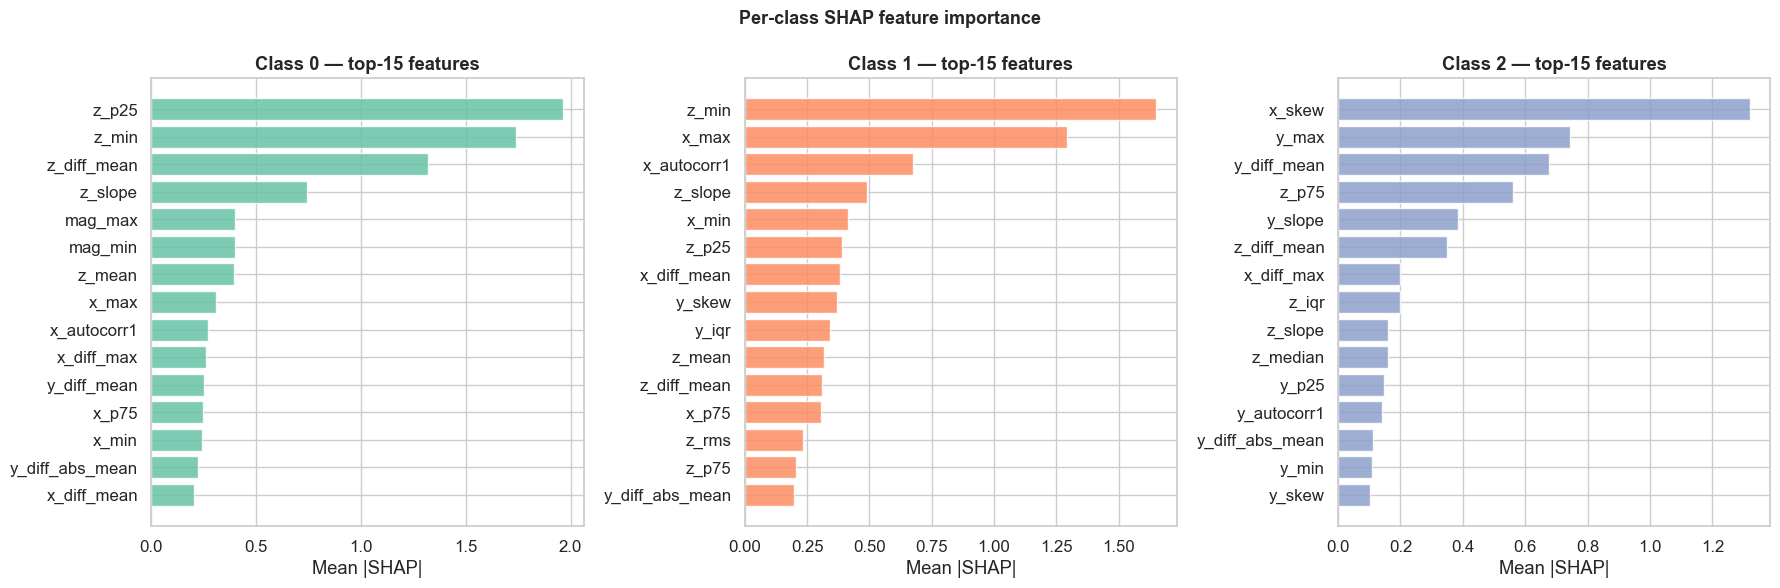

In [33]:
# Per-class SHAP bar charts side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for i, ax in enumerate(axes):
    sv = shap_values[:, :, i]  # (500, 101)
    class_imp = pd.DataFrame({
        'feature': FEATURE_COLS,
        'shap': np.abs(sv).mean(axis=0)
    }).sort_values('shap', ascending=False).head(15)

    ax.barh(class_imp['feature'][::-1], class_imp['shap'][::-1],
            color=COLORS[i], edgecolor='white', alpha=0.85)
    ax.set_title(f'Class {i} — top-15 features', fontweight='bold')
    ax.set_xlabel('Mean |SHAP|')

plt.suptitle('Per-class SHAP feature importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

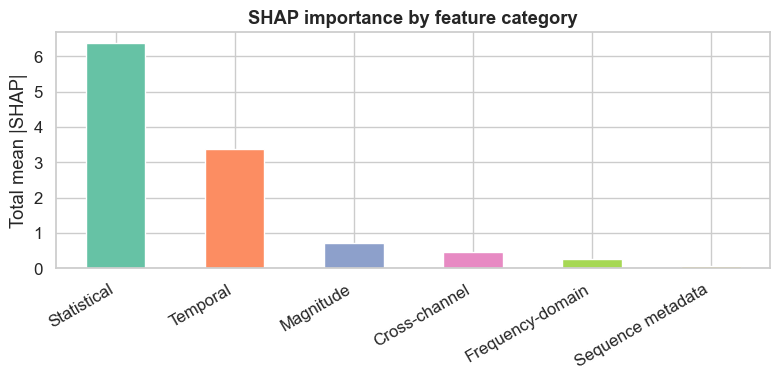

category
Statistical          6.368154
Temporal             3.367971
Magnitude            0.713926
Cross-channel        0.458441
Frequency-domain     0.271417
Sequence metadata    0.076279


In [34]:
# Grouped SHAP importance by feature category
def categorise(feat_name):
    if 'fft' in feat_name:
        return 'Frequency-domain'
    elif any(k in feat_name for k in ['slope','diff','autocorr','zc','resid']):
        return 'Temporal'
    elif feat_name.startswith('corr_') or feat_name.startswith('xi_'):
        return 'Cross-channel'
    elif feat_name.startswith('mag_'):
        return 'Magnitude'
    elif feat_name in ['n_obs','duration','dt_mean','dt_std','dt_min','dt_max']:
        return 'Sequence metadata'
    else:
        return 'Statistical'

mean_shap['category'] = mean_shap['feature'].apply(categorise)
cat_shap = mean_shap.groupby('category')['importance'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
cat_shap.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', len(cat_shap)), edgecolor='white')
ax.set_title('SHAP importance by feature category', fontweight='bold')
ax.set_ylabel('Total mean |SHAP|')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(cat_shap.to_string())

### 5.2 Model Comparison Summary

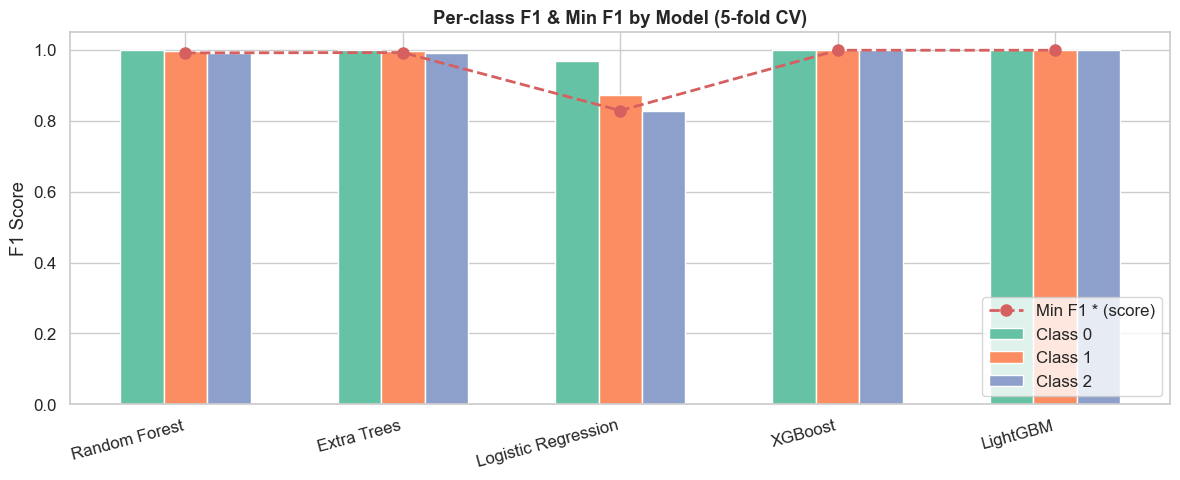

In [35]:
metrics_list = []
for name, res in results.items():
    for i in range(3):
        metrics_list.append({
            'Model': name,
            'Class': f'Class {i}',
            'F1': res['f1_per_class'][i]
        })

metrics_df = pd.DataFrame(metrics_list)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results))
width = 0.2
model_names = list(results.keys())

for i, cls in enumerate(range(3)):
    vals = [results[m]['f1_per_class'][i] for m in model_names]
    ax.bar(x + (i - 1) * width, vals, width, label=f'Class {i}',
           color=COLORS[i], edgecolor='white')

# Min-F1 markers
min_vals = [results[m]['min_f1'] for m in model_names]
ax.plot(x, min_vals, 'r--o', linewidth=2, markersize=8, label='Min F1 * (score)', zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score')
ax.set_title('Per-class F1 & Min F1 by Model (5-fold CV)', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Test-Set Inference & Submission

In [36]:
# ── Predict on test set ───────────────────────────────────────────────────────
y_test_pred = best_pipeline.predict(X_test)

submission = pd.DataFrame({
    'maneuver_id': test_feat['maneuver_Id'].values,
    'class': y_test_pred
})

# Align to submission_example column order
submission = submission.sort_values('maneuver_id').reset_index(drop=True)

print("Submission file preview:")
display(submission.head(10))

print("\nPredicted class distribution (test):")
print(submission['class'].value_counts().sort_index())

submission.to_csv('submission.csv', index=False)
print("\n submission.csv saved!")

Submission file preview:


,maneuver_id,class
0,25705,1
1,25706,0
2,25707,0
3,25708,0
4,25709,0
5,25710,0
6,25711,0
7,25712,0
8,25713,0
9,25714,0



Predicted class distribution (test):
class
0    4313
1    1619
2     419
Name: count, dtype: int64

 submission.csv saved!
